In [1]:
""" Used when checked out from Git """
import sys
import os
def add_local():
    d = os.getcwd()
    assert d[-9:] == "notebooks", "This code assume that the notebook is run out of 'notebooks'. Remove this code if not needed"
    sys.path.insert( 0, d[:-10] )
    print(f"Added '{d[:-10]}' to the import path")
add_local()


Added 'C:\Users\hans\OneDrive\Python3\packages\cdxcore' to the import path


[DynaAx($subplot#0(0,0)), DynaAx($subplot#1(0,1))]


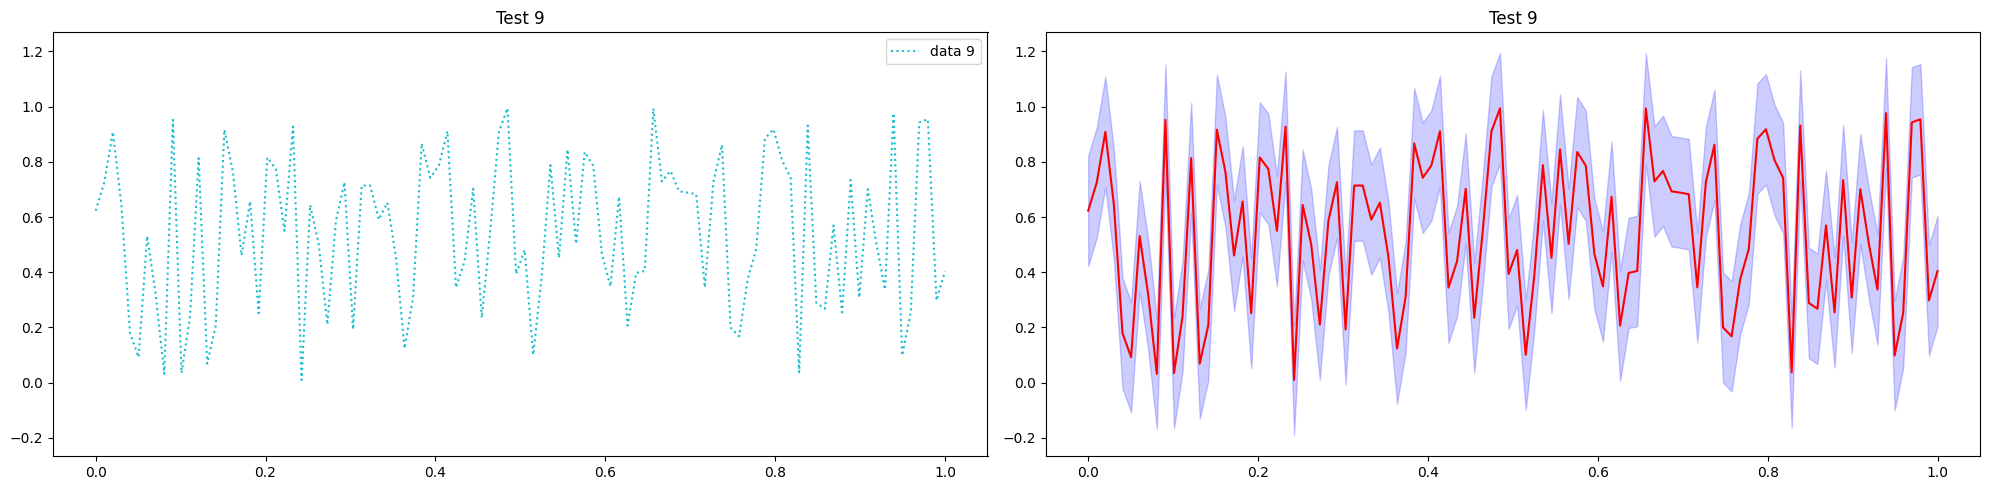

In [13]:
"""
Animated line plots with 'store'
"""

%matplotlib inline
import numpy as np
from cdxcore.dynaplot import figure

x  = np.linspace(0,1,100)
pm = 0.2

fig = figure(col_size=10)
ax  = fig.add_subplot()
ax2 = fig.add_subplot()
ax2.sharey(ax)
store = fig.store()
print(fig.axes)

fig.render()

import time
for i in range(10):
    y = np.random.random(size=(100,))
    ax.set_title(f"Test {i}")
    ax2.set_title(f"Test {i}")

    store.remove() # delete all prviously stored elements
    store += ax.plot(x,y,":", label=f"data {i}")
    store += ax2.plot(x,y,"-",color="red", label=f"data {i}")
    store += ax2.fill_between( x, y-pm, y+pm, color="blue", alpha=0.2 )
    store += ax.legend()

    fig.render()
    time.sleep(0.5)
fig.close()

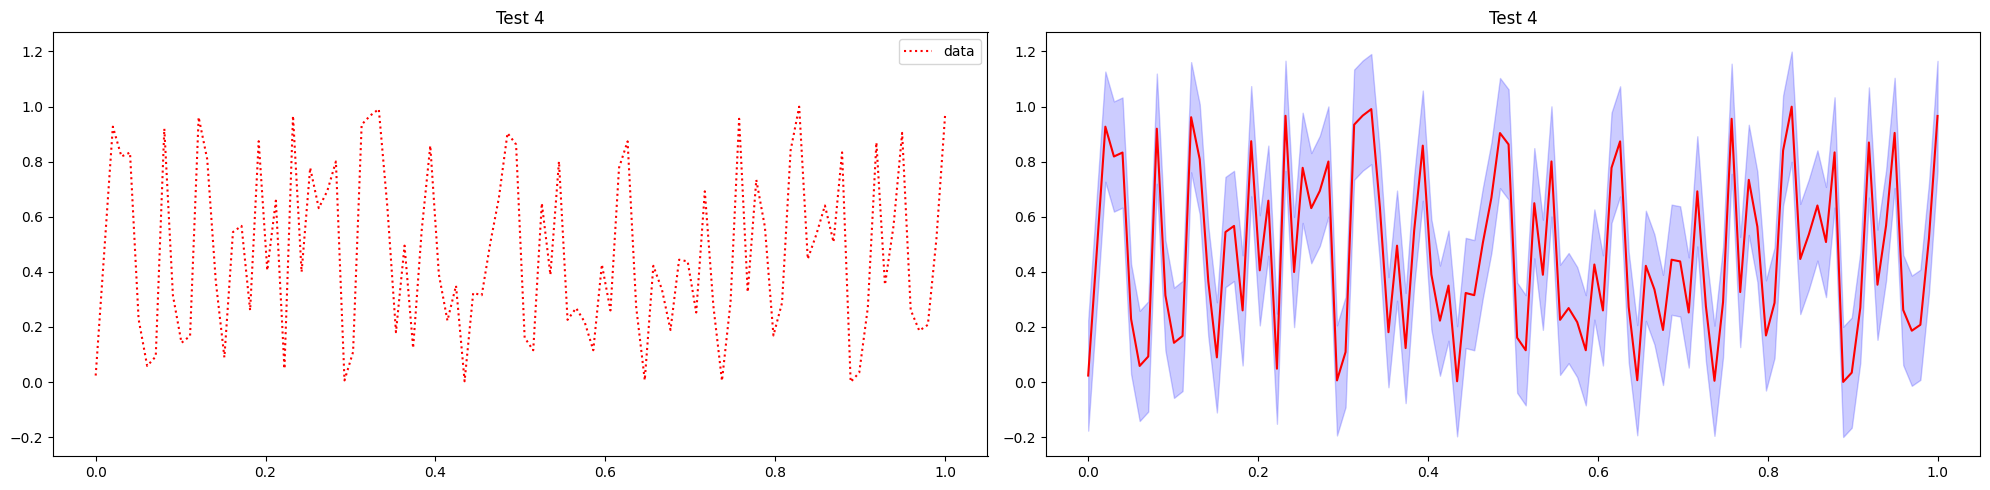

/done


In [3]:
%matplotlib inline
"""
Animation with lines, and an example with confidence intervals
Updating the line plots manually instead of using remove/add with 'store'
"""

import numpy as np
from cdxcore.dynaplot import figure

x = np.linspace(0,1,100)

fig = figure(col_size=10)

ax = fig.add_subplot()
ax.set_title("Test")
y = np.random.random(size=(100,))
l = ax.plot(x,y,":",color="red", label="data")[0]
ax.legend()

ax2 = fig.add_subplot()
ax2.set_title("Test Confidence Band")
l2 = ax2.plot(x,y,"-",color="red", label="data")
pm = 0.2
f2 = ax2.fill_between( x, y-pm, y+pm, color="blue", alpha=0.2 )
ax2.sharey(ax)

fig.render()

import time
for i in range(5):
    time.sleep(0.5)
    y = np.random.random(size=(100,))
    ax.set_title("Test %ld" % i)
    l.set_ydata( y )
    ax2.set_title("Test %ld" % i)
    l2[0].set_ydata( y )
    f2.remove()
    f2 = ax2.fill_between( x, y-pm, y+pm, color="blue", alpha=0.2 )

    fig.render()
fig.close()
print("/done")    

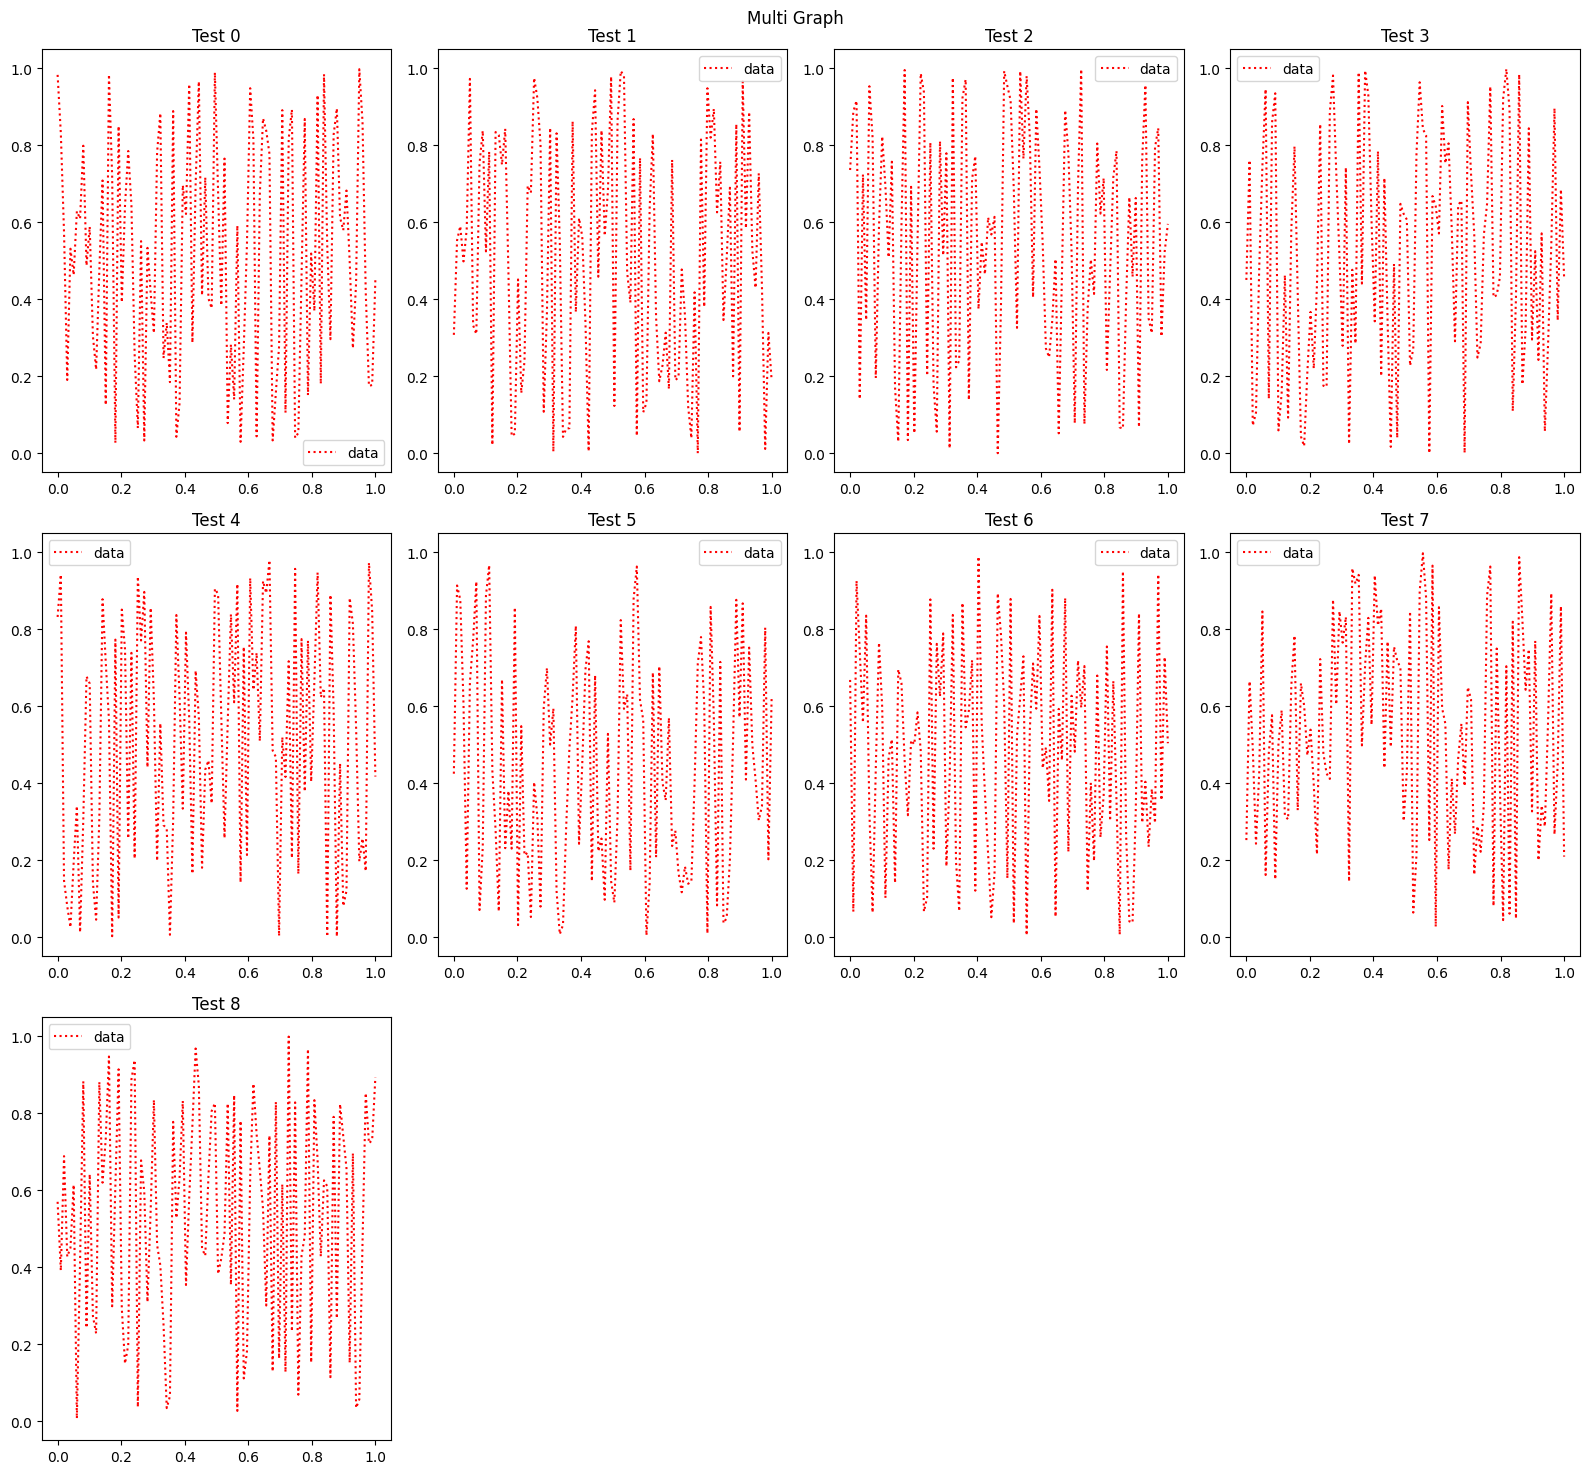

/done


In [4]:
%matplotlib inline
"""
Example of distributing the subplots, incuding the use of "next_row()"
Note how the legends move as they are not set with 'loc='
"""

import numpy as np
from cdxcore.dynaplot import figure
 
x = np.linspace(0,1,100)

fig    = figure(title="Multi Graph", fig_size=(10,6), columns=4)
lines  = []
ref_ax = None
for k in range(9):
    ax = fig.add_subplot()
    ax.set_title("Test %ld" % k)
    y = np.random.random(size=(100,1))
    l = ax.plot(x,y,":",color="red", label="data")
    lines.append(l)
    ax.legend()
    
    if not ref_ax is None:
        ax.sharey(ref_ax)
        ax.sharex(ref_ax)
    else:
        ref_ax = ax
fig.render()

import time
for i in range(5):
    time.sleep(0.2)
    for l in lines:
        y = np.random.random(size=(100,1))
        l[0].set_ydata( y )
    fig.render()
fig.close()
print("/done")

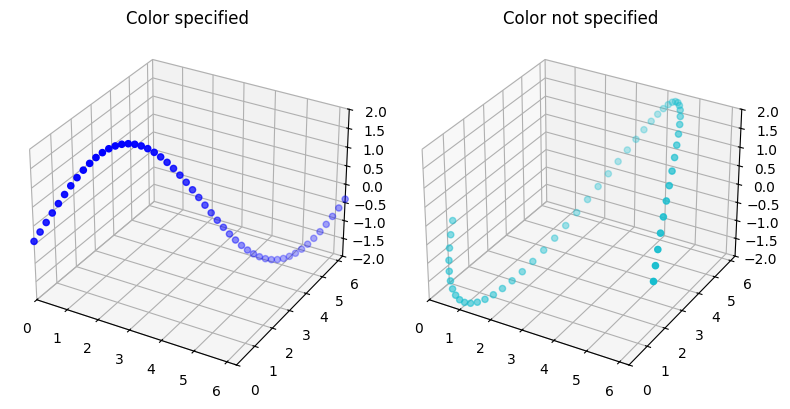

/done


In [5]:
"""
Animated 3D graphs
"""

%matplotlib inline
import numpy as np
from cdxcore.dynaplot import figure
import math
    
x = np.linspace(0.,2.*math.pi,51)
y = x

fig = figure()
ax1  = fig.add_subplot(projection='3d')
ax2  = fig.add_subplot(projection='3d')
ax1.set_xlim(0.,2.*math.pi)
ax1.set_ylim(0.,2.*math.pi)
ax1.set_zlim(-2,+2)
ax1.set_title("Color specified")
ax2.set_xlim(0.,2.*math.pi)
ax2.set_ylim(0.,2.*math.pi)
ax2.set_zlim(-2,+2)
ax2.set_title("Color not specified")
fig.render()
r1 = None
r2 = None
import time
for i in range(50):
    time.sleep(0.01)
    z = np.cos( float(i)/10.+x )+np.sin( float(i)/2.+y )
    if not r1 is None: r1.remove()
    if not r2 is None: r2.remove()
    r1 = ax1.scatter( x,y,z, color="blue" )
    r2 = ax2.scatter( 2.*math.pi-x,math.pi*(1.+np.sin( float(i)/2.+y )),z )
    fig.render()
fig.close()
print("/done")


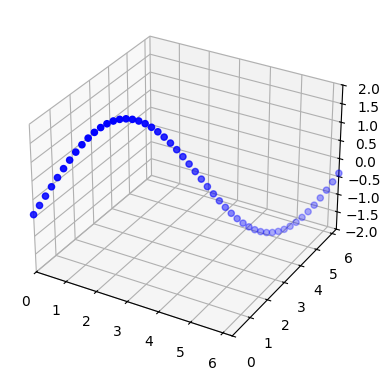

/done


In [6]:
"""
3D example with clear() which preserves the color of the animation
I suppose clear() works for all graphs
"""

%matplotlib inline
import numpy as np
from cdxcore.dynaplot import figure
import math
    
x = np.linspace(0.,2.*math.pi,51)
y = x

fig = figure()
ax  = fig.add_subplot(projection='3d')
ax.set_xlim(0.,2.*math.pi)
ax.set_ylim(0.,2.*math.pi)
ax.set_zlim(-2,+2)
r = None
import time
for i in range(50):
    time.sleep(0.01)
    ax.clear()
    ax.set_xlim(0.,2.*math.pi)
    ax.set_ylim(0.,2.*math.pi)
    ax.set_zlim(-2,+2)
    z = np.cos( float(i)/10.+x )+np.sin( float(i)/2.+y )
    r = ax.scatter( x,y,z, color="blue" )
    fig.render()
fig.close()
print("/done")




Plotting an image with IPython


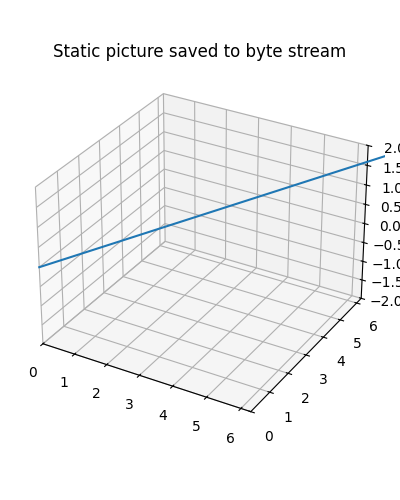

In [7]:
%matplotlib inline
"""
Example which shows how to use DynamicPlot to generate a figure bitmap
"""

import numpy as np
from cdxcore.dynaplot import figure
import math
from IPython.display import display, Image

x = np.linspace(0.,2.*math.pi,51)
y = x

# generate a figure
fig = figure()
ax  = fig.add_subplot(projection='3d')
ax.set_xlim(0.,2.*math.pi)
ax.set_ylim(0.,2.*math.pi)
ax.set_zlim(-2,+2)
ax.set_title("Static picture saved to byte stream")
ax.plot(x,y*2)
picture_data = fig.to_bytes()
fig.close()

print("Plotting an image with IPython")

im = Image(data=picture_data)
display(im)



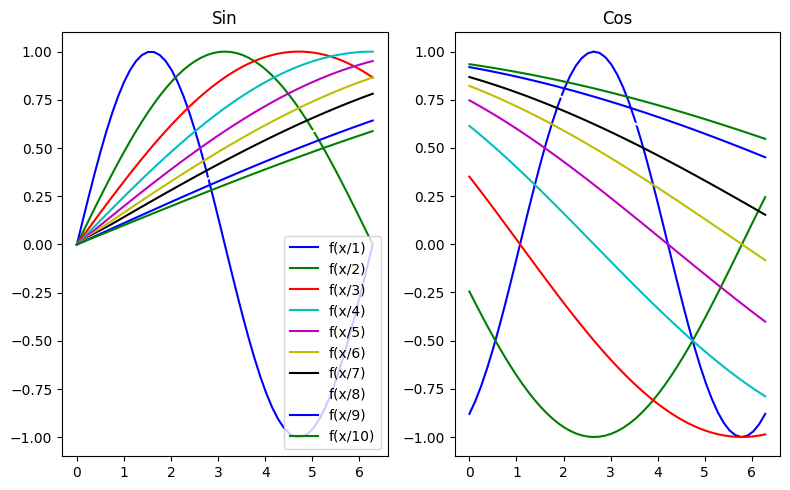

In [8]:
"""
Using consistent colors in two graphs
"""

%matplotlib inline
import numpy as np
import math
import time
from cdxcore.dynaplot import figure, color_base   # 'figure' is an alias for DynaFig

x = np.linspace(0.,2.*math.pi,51)

fig = figure(fig_size=(14,6))
ax = fig.add_subplot("Sin")
store = fig.store()
# draw 10 lines in the first sub plot, and add a legend
for i in range(10):
    y = np.sin(x/(i+1))
    ax.plot( x, y, color=color_base(i), label=f"f(x/{i+1})" )
ax.legend(loc="lower right")

# draw 10 lines in the second sub plot.
# use the same colors for the same scaling of 'x'
ax = fig.add_subplot("Cos")

for i in range(10):
    z = np.cos(x/(i+1))
    store += ax.plot( x, z, color=color_base(i) )
fig.render()

# animiate, again with the same colors
for p in np.linspace(0.,4.,11,endpoint=False):
    time.sleep(0.1)
    store.clear() # alias for 'remove'
    for i in range(10):
        z = np.cos((x+p)/(i+1))
        store += ax.plot( x, z, color=color_base(i) )
    fig.render()

fig.close()

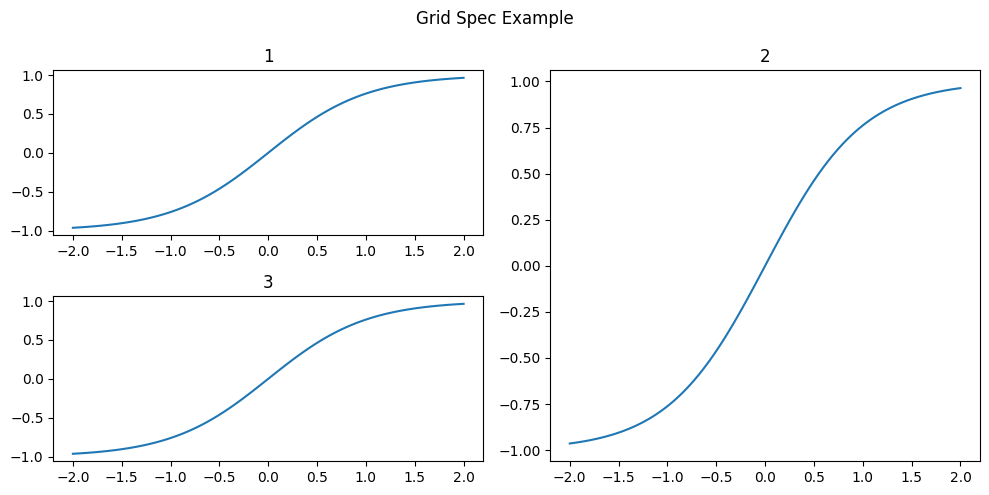

In [9]:
"""
Grid spec example
"""

%matplotlib inline
from cdxcore.dynaplot import figure
import numpy as np
x = np.linspace(-2.,+2,101)
y = np.tanh(x)
fig = figure("Grid Spec Example", figsize=(10,5))
gs  = fig.add_gridspec(2,2)

ax = fig.add_subplot("1", spec_pos=gs[0,0] )
ax.plot(x,y)
ax = fig.add_subplot("2", spec_pos=gs[:,1] )
ax.plot(x,y)
ax = fig.add_subplot("3", spec_pos=gs[1,0] )
ax.plot(x,y)
fig.close()


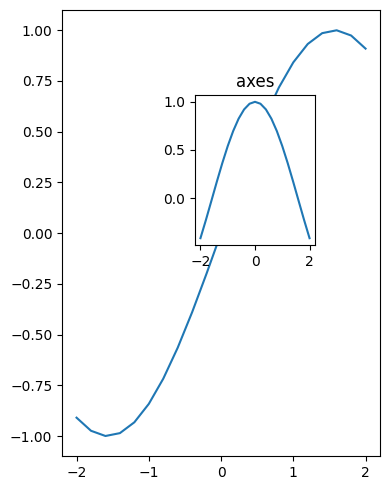

C:\Users\hans\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


In [2]:
"""
Add plots post render
"""
%matplotlib inline
from cdxbasics.dynaplot import figure
import numpy as np

x = np.linspace(-2.,+2,21)

fig = figure()
ax = fig.add_subplot(tight=False)
ax.plot( x, np.sin(x) )
fig.render()

ax = fig.add_axes( "axes", (0.5,0.5,0.3,0.3))
ax.plot( x, np.cos(x) )
fig.close()


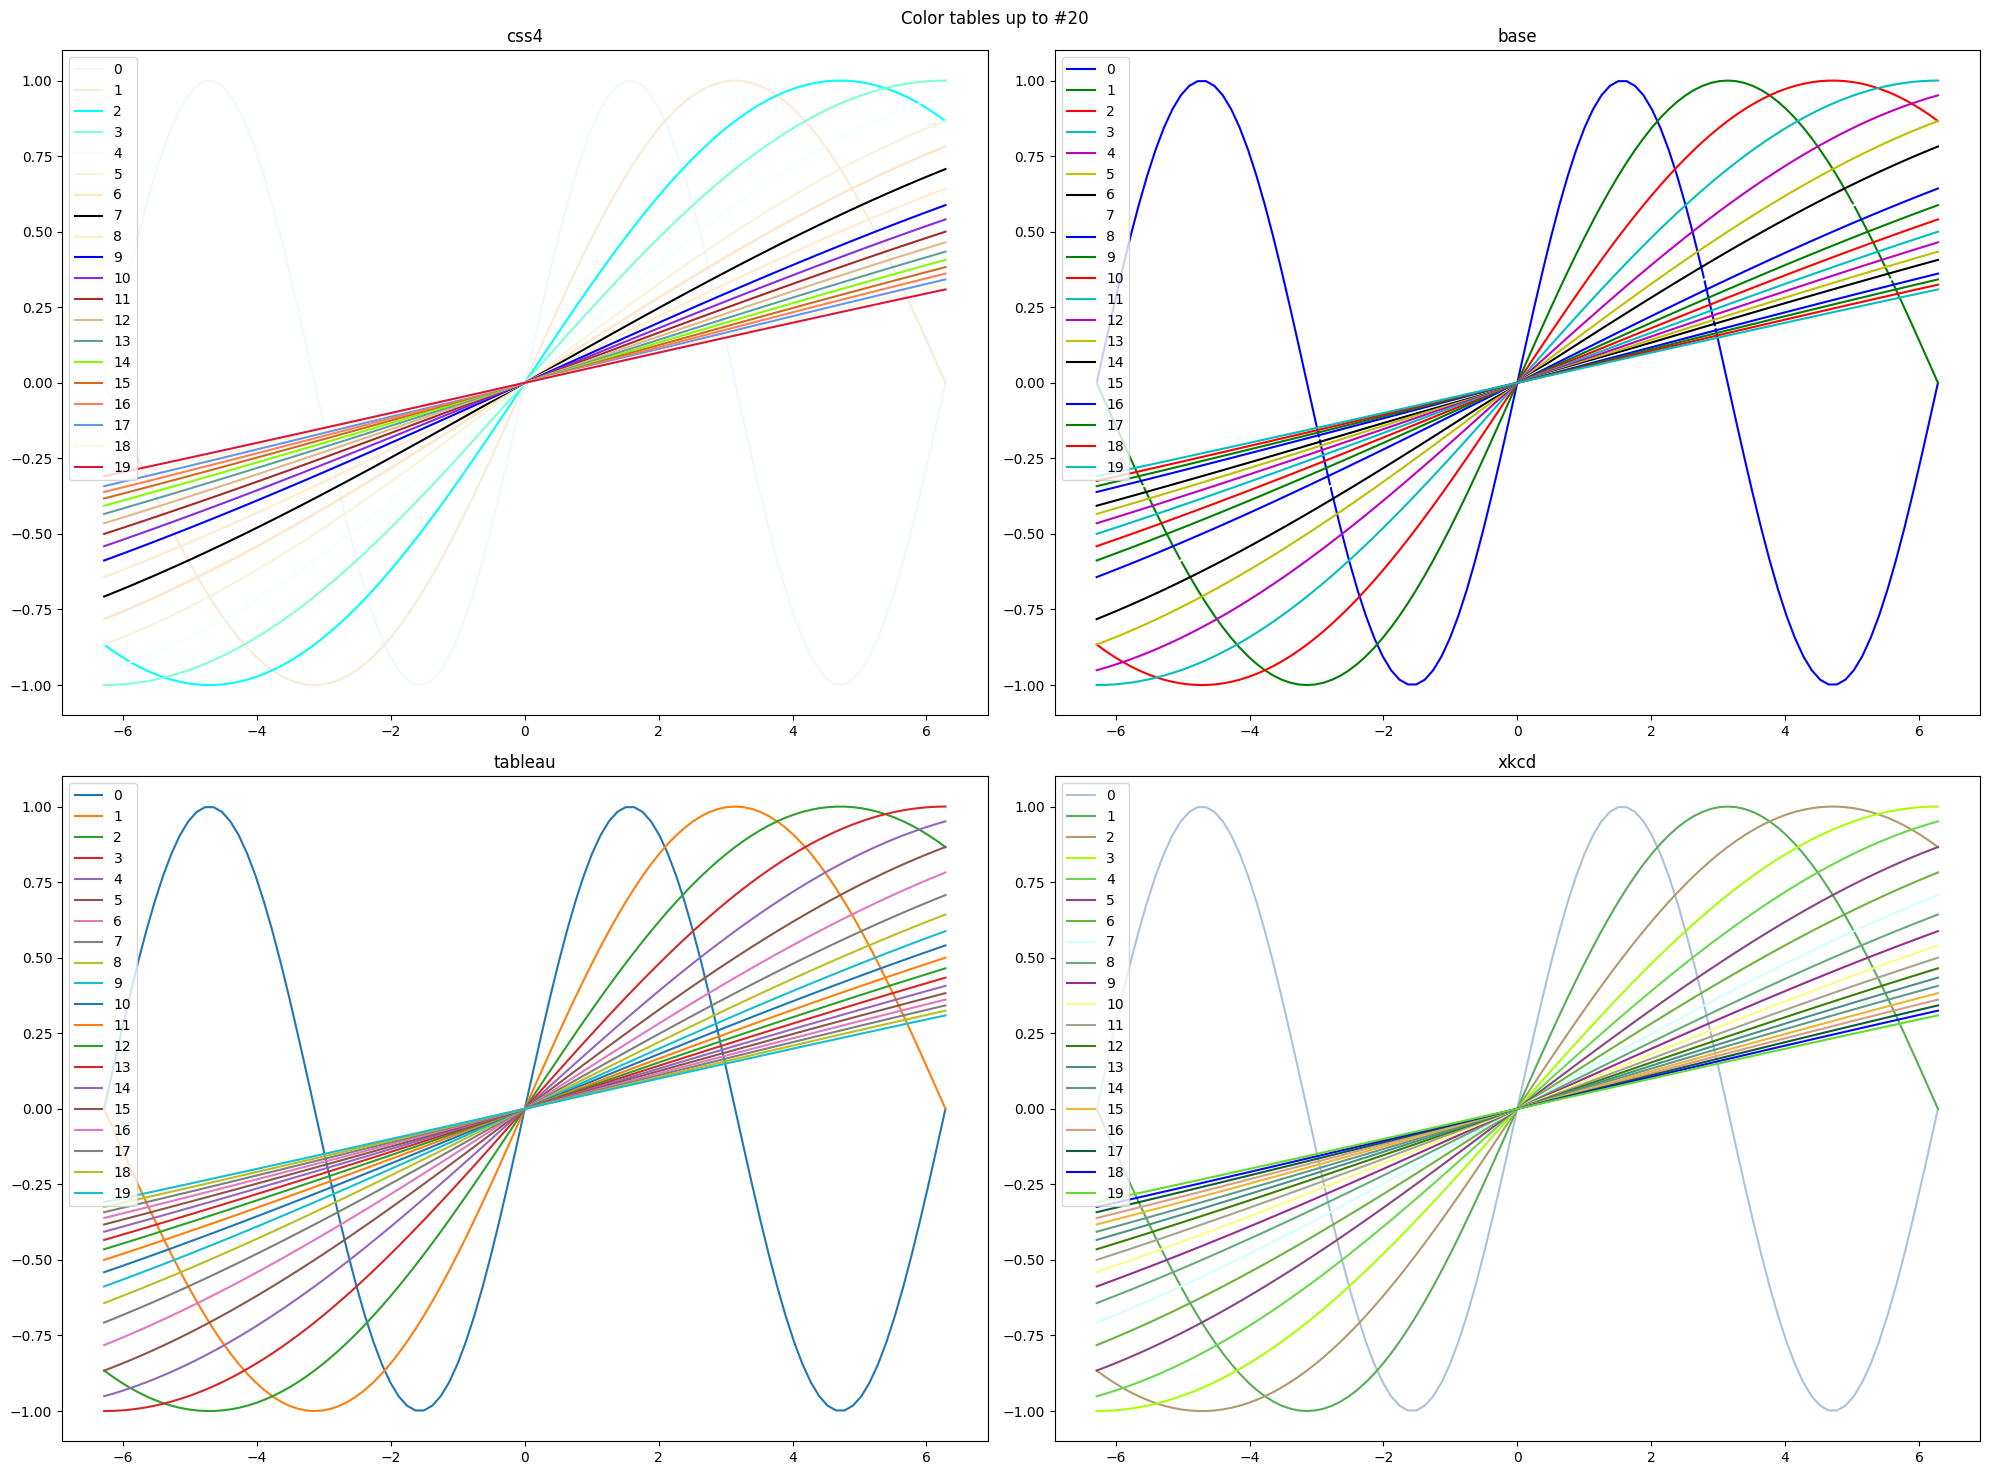

In [11]:
"""
Showing all color tables
"""
%matplotlib inline
from cdxcore.dynaplot import figure, color_names, color
import numpy as np
x = np.linspace(-2.*np.pi,+2*np.pi,101)
N = 20
fig = figure(f"Color tables up to #{N}", figsize=(20,15), columns=2)
for color_name in color_names:
    ax  = fig.add_subplot(color_name)
    for i in range(N):
        r =1./(i+1)
        ax.plot( x, np.sin(x*r), color=color(i,color_name), label=f"{i}" )
        ax.legend(loc="upper left")
fig.close()
